# Credit Card Fraud Detection using Random Forest
Goal: The goal of this project is to build a model that can detect fraudulent credit card transactions. Therefore, I am using Random Forest and CNN to evaluate the dataset.

Key Challenge: The dataset is highly imbalanced because fraud transactions are much smaller than normal transactions. Because of this, accuracy alone is not enough to judge the model.



### Importing the needed libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import average_precision_score

### Step 2: Load the Dataset

In [3]:
# Load the dataset

df = pd.read_csv("creditcard.csv")

df.head() # used to take quick peek on the dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# checking how many normal and fraud transactions we have
df["Class"].value_counts()

,count
Class,
0,284315
1,492


Key columns:
- V1–V28: PCA-transformed features
- Time: seconds elapsed between transactions
- Amount: transaction amount
- Class: target variable where 0 = normal transaction and 1 = fraud transaction

The dataset is imbalanced because there are many more normal transactions than fraud transactions.

### Splitting the features and target

In [6]:
X = df.drop("Class", axis=1) # input --> What the model learns from
y = df["Class"] # target --> What the model is trying to predict

### Scaling the data

In [7]:
# scale "Time" and "Amount" so values are on a similar range
# V1 to V28 are already PCA-transformed, so we only scale Time and Amount

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

### Splitting into Train and Test

In [8]:
# check missing values in the target column
print("Missing values in Class column:", df["Class"].isnull().sum())

# check class counts
print(df["Class"].value_counts(dropna=False))

Missing values in Class column: 0
Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# remove rows where Class is missing
df = df.dropna(subset=["Class"])

# convert Class column to integer
df["Class"] = df["Class"].astype(int)

# check again
print("Missing values in Class column after cleaning:", df["Class"].isnull().sum())
print(df["Class"].value_counts())

Missing values in Class column after cleaning: 0
Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
# X is the input features
# y is the output label

X = df.drop("Class", axis=1)
y = df["Class"]

In [11]:
# check if X has missing values
print(X.isnull().sum().sum())

0


In [12]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets: 20% for testing & 80% for training
# stratify=y keeps the same fraud ratio in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Using Oversampling to address the class imbalance

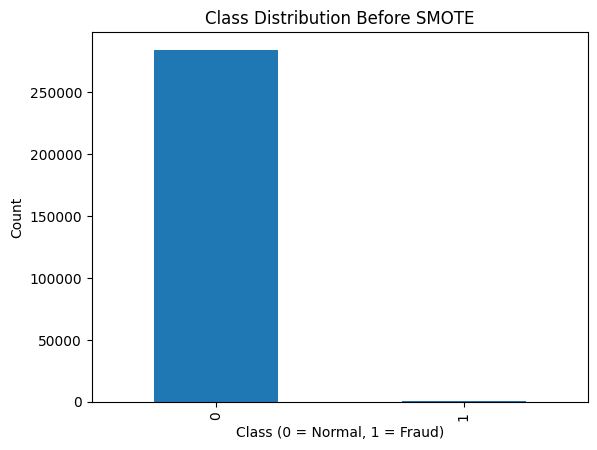

In [13]:
# shows how imbalanced the dataset is before SMOTE

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [14]:
# creates synthetic fraud samples to balance the training data
# SMOTE is only applied on training data to avoid data leakage

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

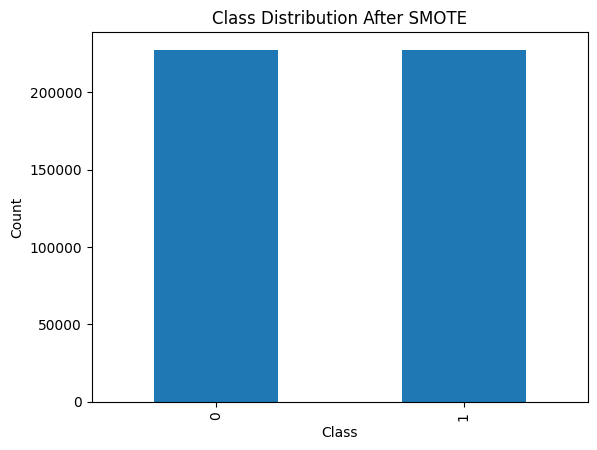

In [15]:
# shows the balanced dataset after SMOTE

pd.Series(y_train_res).value_counts().plot(kind="bar")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Training the Random Forest Model

In [16]:
# Random Forest is an ensemble model that uses many decision trees
# n_estimators = number of trees
# max_depth helps control overfitting
# n_jobs=-1 uses all CPU cores to train faster

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=12, n_jobs=-1, random_state=42)

### Making predictions

In [17]:
# predicts the final class labels
y_pred = rf_model.predict(X_test)

# predicts the probability of fraud
y_scores = rf_model.predict_proba(X_test)[:, 1]

### Final Evaluation

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



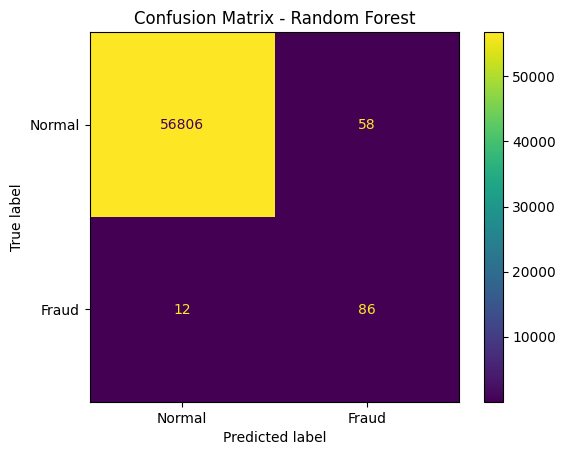

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

AUPRC: 0.807845159741038
Average Precision Score: 0.8087429610134841


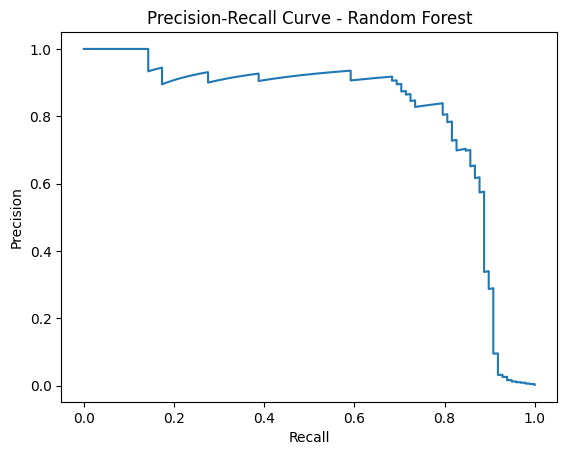

In [20]:
# Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_scores)

pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_scores)

print("AUPRC:", pr_auc)
print("Average Precision Score:", avg_precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

### Feature Importance

In [21]:
# shows which features were most useful for the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
14,V14,0.228412
10,V10,0.126571
4,V4,0.116357
12,V12,0.104634
17,V17,0.081377
3,V3,0.072368
11,V11,0.048714
16,V16,0.042320
2,V2,0.039452
9,V9,0.027727


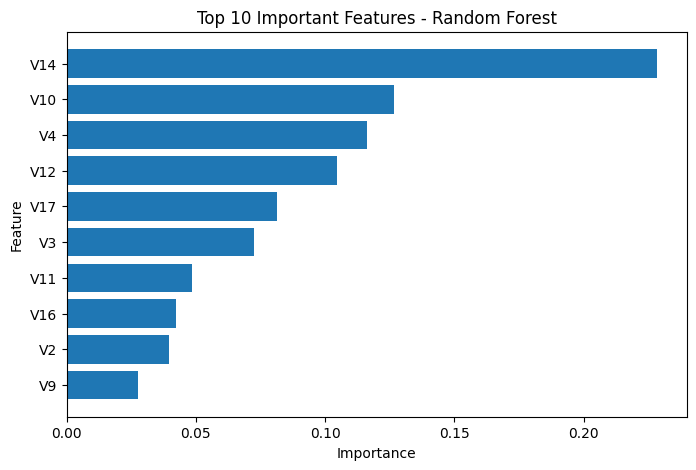

In [22]:
# plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

### Conclusion for Random Forest

The Random Forest model was used to detect credit card fraud in a highly imbalanced dataset. Since fraud transactions are much smaller than normal transactions, SMOTE was applied only to the training data to balance the classes. The model was evaluated using precision, recall, F1-score, confusion matrix, and AUPRC because accuracy alone can be misleading for fraud detection problems.

# Credit Card Fraud Detection using CNN with Keras + TensorFlow

This section builds a CNN model using a similar format to Lab 5. Since this dataset is not image data, the features are reshaped into a 1D format so the CNN can process the transaction features.

### Importing TensorFlow and Keras libraries

In [23]:
import tensorflow as tf
from tensorflow import keras

# Sequential model lets us define a stack of neural network layers
from keras.models import Sequential

# import the core layers
from keras.layers import Dense, Dropout, Activation, Flatten

# CNN layers for 1D tabular data
from keras.layers import Conv1D, MaxPooling1D

# utility for one-hot encoding
from tensorflow.keras.utils import to_categorical

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, auc
from sklearn.utils.class_weight import compute_class_weight

In [24]:
# checking the class distribution

df["Class"].value_counts()

,count
Class,
0,284315
1,492


### Splitting the features and target

In [25]:
X = df.drop("Class", axis=1) # input features
y = df["Class"] # target label

### Scaling the data

In [26]:
# scale Time and Amount

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

### Splitting into Train and Test

In [27]:
# split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Reshaping the data for CNN

In [28]:
# CNN needs 3D input: samples, features, channels
# We have 30 features, so we reshape it into 30 by 1

X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(227845, 30, 1)
(56962, 30, 1)


### One-Hot Encoding the output

In [29]:
# OneHotEncoding for the output label
# 0 = normal, 1 = fraud

y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

print(y_train_cat.shape)
print(y_train_cat[:10])

(227845, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


### Handling class imbalance with class weights

In [30]:
# class weights help the CNN pay more attention to the fraud class

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


### Define the Network Architecture

In [31]:
# Declare Sequential model for our network

cnn_model = Sequential()

In [32]:
# CNN first layer
# 32 filters are used to learn patterns from transaction features

cnn_model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train_cnn.shape[1], 1),
        padding="same"
    )
)

print(cnn_model.output_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(None, 30, 32)


In [33]:
# More hidden layers

cnn_model.add(Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"))
print(cnn_model.output_shape)

# Pooling layer
cnn_model.add(MaxPooling1D(pool_size=2))
print(cnn_model.output_shape)

# Dropout layer to avoid overfitting
cnn_model.add(Dropout(0.25))

(None, 30, 32)
(None, 15, 32)


In [34]:
# Fully connected Dense layers

cnn_model.add(Flatten())
print(cnn_model.output_shape)

cnn_model.add(Dense(128, activation="relu"))
print(cnn_model.output_shape)

cnn_model.add(Dropout(0.5))

# Output layer
# 2 neurons because we have 2 classes: normal and fraud

cnn_model.add(Dense(2, activation="softmax"))
print(cnn_model.output_shape)

(None, 480)
(None, 128)
(None, 2)


### Compile the model

In [35]:
cnn_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print(cnn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,058 (254.13 KB)

 Trainable params: 65,058 (254.13 KB)

 Non-trainable params: 0 (0.00 B)

None


### Training the CNN Model

In [41]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.25,
    batch_size=32,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)

# batch_size: number of samples per update
# epochs: number of times the model goes through the training data
# validation_split: part of training data used for validation
# class_weight: helps with imbalanced classes

Epoch 1/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9389 - loss: 0.3504 - val_accuracy: 0.9870 - val_loss: 0.1274
Epoch 2/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9443 - loss: 0.4116 - val_accuracy: 0.9823 - val_loss: 0.1623
Epoch 3/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9625 - loss: 0.4501 - val_accuracy: 0.9801 - val_loss: 0.1526
Epoch 4/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9754 - loss: 0.3671 - val_accuracy: 0.9857 - val_loss: 0.1620
Epoch 5/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9717 - loss: 0.4181 - val_accuracy: 0.9662 - val_loss: 0.1863
Epoch 6/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9638 - loss: 0.3919 - val_accuracy: 0.9685 - val_loss: 0.1967
Epoch 7/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9766 - loss: 0.4041 - val_accuracy: 0.9789 - val_loss: 0.2102
Epoch 8/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9670 - loss: 0

### Plotting training accuracy and loss

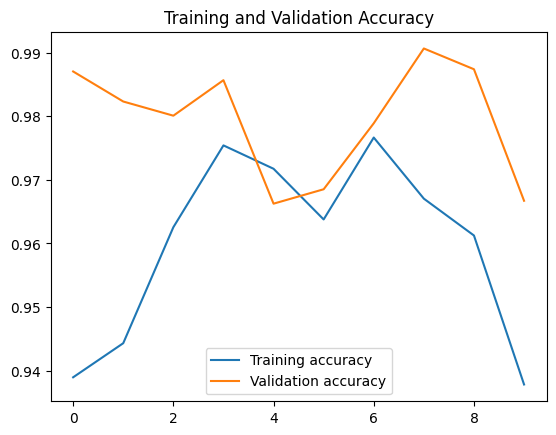

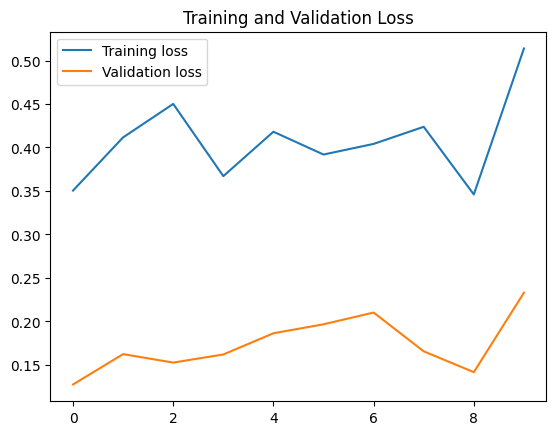

In [42]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(accuracy))

plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure()

plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Testing the CNN Model

In [43]:
# predicts probabilities for each class

predicted_classes = cnn_model.predict(X_test_cnn)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [44]:
# convert probabilities into final class labels

y_pred_cnn = np.argmax(predicted_classes, axis=1)

print(y_pred_cnn[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [45]:
# Testing accuracy

score = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=1)

print("The accuracy is:", score[1])

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9669 - loss: 0.2396
The accuracy is: 0.966925323009491


#### The accuracy is around 96.7%

### Final Evaluation

In [46]:
print(classification_report(y_test, y_pred_cnn))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.84      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.90      0.53     56962
weighted avg       1.00      0.97      0.98     56962



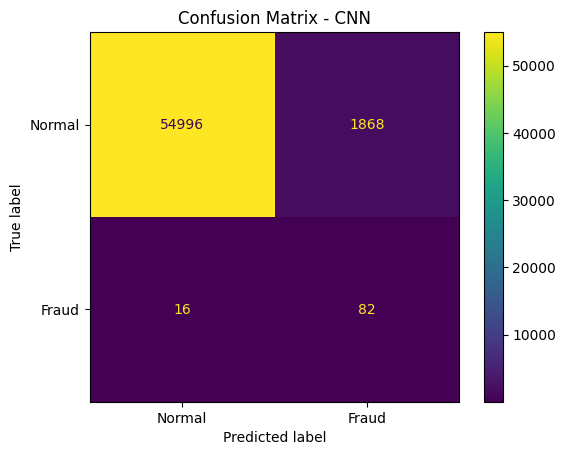

In [47]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_cnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - CNN")
plt.show()

In [48]:
# AUPRC for CNN model

from sklearn.metrics import precision_recall_curve, auc, average_precision_score

# predicted_classes has probabilities for class 0 and class 1
# class 1 = fraud, so we take column 1
y_score_cnn = predicted_classes[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_score_cnn)

cnn_auprc = auc(recall, precision)
cnn_avg_precision = average_precision_score(y_test, y_score_cnn)

print("CNN AUPRC:", cnn_auprc)
print("CNN Average Precision Score:", cnn_avg_precision)

CNN AUPRC: 0.7003381976047066
CNN Average Precision Score: 0.6461935058932158


### Conclusion for CNN

The CNN model was used as a different approach to see if a deep learning model could detect fraud patterns from the transaction features. Since this dataset is tabular, the data was reshaped into a 1D format before training. The model used Conv1D layers to process the features and learn patterns related to normal and fraudulent transactions. Because fraud cases are very rare compared to normal transactions, class weights were used so the CNN would pay more attention to the fraud class. Overall, the CNN gave another way to compare model performance with the Random Forest model.